# PTB-XL ECG Machine Learning Capstone: Classification Track (Part B)
## Objective: Ensemble & Neural Models for Dominant Cardiac Diagnostic Category

This notebook implements **Classification Track Part B** under the Capstone rubric.
Using the *same* patient-stratified 80:20 split and identical preprocessing pipeline
as Part A, it benchmarks five advanced learners:

1. **AdaBoost Classifier** — adaptive boosting on Decision Stump base learners (tuned `n_estimators`)
2. **Gradient Boosting Machine (GBM)** — stage-wise additive boosting (tuned `learning_rate`)
3. **XGBoost Classifier** — extreme gradient boosting with `logloss` objective
4. **Bagging Classifier** — variance-reduction ensemble of Decision Trees (tuned `n_estimators`)
5. **Multi-Layer Perceptron (MLP)** — fully connected neural classifier (tuned hidden layer size)

All models are compared on **Accuracy** and **Weighted-F1** and the winner is serialised
to `/models/best_classification_model_partB.joblib`.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
palette = sns.color_palette('Set2')

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("WARNING: xgboost not installed — XGBClassifier will be skipped.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded. XGBoost available:", HAS_XGB)


Libraries loaded. XGBoost available: True


---
## Section A: Data Ingestion, Label Collapse & Patient-Stratified Split

Identical pipeline to Part A — single-label hierarchy MI > CD > HYP > STTC > NORM,
patient-level 80:20 stratified split with zero patient leakage.


In [2]:
DATA_DIR   = '../data'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

features_df = pd.read_csv(os.path.join(DATA_DIR, 'stage4_features.csv'))
labels_df   = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_labels.csv'))

label_targets = ['label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP']
df = features_df.merge(
    labels_df[['ecg_id', 'fold'] + label_targets],
    on='ecg_id', how='inner'
)

# Single-label hierarchy collapse
priority_cols = ['label_MI', 'label_CD', 'label_HYP', 'label_STTC', 'label_NORM']
class_names   = ['MI', 'CD', 'HYP', 'STTC', 'NORM']

def collapse_dominant_label(row):
    for col, name in zip(priority_cols, class_names):
        if row[col] == 1:
            return name
    raise ValueError(f"Record {row['ecg_id']} has zero positive labels!")

df['dominant_label'] = df.apply(collapse_dominant_label, axis=1)

# Encode labels to integers for XGBoost compatibility
le = LabelEncoder()
le.fit(class_names)
df['y_int'] = le.transform(df['dominant_label'])

print(f"Total records: {len(df)}")
print("Class balance:")
print(df['dominant_label'].value_counts())


Total records: 21388
Class balance:
dominant_label
NORM    9069
MI      5469
CD      3104
STTC    2428
HYP     1318
Name: count, dtype: int64


In [3]:
# Feature matrix
exclude_cols = {'ecg_id', 'patient_id', 'fold', 'dominant_label', 'y_int',
                'label_NORM', 'label_MI', 'label_STTC', 'label_CD', 'label_HYP'}
feature_cols = [c for c in df.columns if c not in exclude_cols
                and pd.api.types.is_numeric_dtype(df[c])]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Engineer qtc_qrs_ratio
if 'qt_mean' in df.columns and 'qrs_dur_mean' in df.columns:
    df['qtc_qrs_ratio'] = df['qt_mean'] / (df['qrs_dur_mean'].replace(0, np.nan))
    if 'qtc_qrs_ratio' not in feature_cols:
        feature_cols.append('qtc_qrs_ratio')
        print("Engineered feature 'qtc_qrs_ratio' added.")


Feature columns (26): ['n_beats', 'hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rr_rmssd_ms', 'rr_pnn50', 'n_qrs_reliable', 'frac_qrs_reliable', 'delineation_ok', 'pr_mean_ms', 'pr_std_ms', 'qrs_dur_mean_ms', 'qrs_dur_std_ms', 'qt_mean_ms', 'qt_std_ms', 'qtc_mean_ms', 'p_dur_mean_ms', 't_dur_mean_ms', 'p_amp_median_mv', 'r_amp_median_mv', 't_amp_median_mv', 'st_level_median_mv', 'qrs_area_median', 'p_area_median', 't_area_median', 'rs_ratio_median']


In [4]:
# Patient-stratified 80:20 split — zero patient leakage
from sklearn.model_selection import GroupShuffleSplit

patient_ids = df['patient_id'].values
X_all = df[feature_cols].values
y_str = df['dominant_label'].values
y_int = df['y_int'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_all, y_str, groups=patient_ids))

X_train_raw, X_test_raw = X_all[train_idx], X_all[test_idx]
y_train_str, y_test_str = y_str[train_idx], y_str[test_idx]
y_train_int, y_test_int = y_int[train_idx], y_int[test_idx]

# Leakage check
train_patients = set(patient_ids[train_idx])
test_patients  = set(patient_ids[test_idx])
overlap = train_patients & test_patients
assert len(overlap) == 0, f"LEAKAGE DETECTED: {len(overlap)} patients in both sets!"
print(f"Train: {len(train_idx)} records | Test: {len(test_idx)} records | Patient overlap: {len(overlap)}")

# Impute + Scale (fit on train only)
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_test  = scaler.transform(imputer.transform(X_test_raw))
print("Preprocessing complete.")


Train: 17080 records | Test: 4308 records | Patient overlap: 0
Preprocessing complete.


---
## Section B: Model Training — Ensemble & Neural Classifiers

Models evaluated:
1. **Random Forest** (tuned `n_estimators`, MDI feature importance)
2. **AdaBoost** (tuned `n_estimators` and `learning_rate`)
3. **Gradient Boosting Machine (GBM)** (Supplementary baseline comparison)
4. **XGBoost** (Primary gradient booster fulfilling Rubric Item 8)
5. **Bagging Classifier** (tuned `n_estimators` with tree base)
6. **MLP Classifier** (multi-layer architecture, activation, and regularization)

Each model is tuned via `GridSearchCV` (3-fold stratified CV, scoring=`f1_weighted`).
Hyperparameter grids are deliberately wide to prevent boundary-hugging.


In [5]:
clf_results = []
clf_cms     = {}
clf_models  = {}

def compute_ovr_auc(model, X_te, y_te_str, class_names=None):
    try:
        probs = model.predict_proba(X_te)
    except AttributeError:
        return np.nan
    # Always bind to the model's own class order, never an external list
    y_te_bin = label_binarize(y_te_str, classes=model.classes_)
    return roc_auc_score(y_te_bin, probs, average='weighted', multi_class='ovr')

def eval_clf(name, model, X_tr, y_tr, X_te, y_te):
    'Fit, predict on test, record metrics including ROC-AUC.'
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc   = accuracy_score(y_te, preds)
    prec  = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec   = recall_score(y_te, preds, average='weighted', zero_division=0)
    wf1   = f1_score(y_te, preds, average='weighted', zero_division=0)
    auc_v = compute_ovr_auc(model, X_te, y_te, class_names)
    clf_results.append({
        'Algorithm': name,
        'Accuracy': round(acc, 4),
        'Precision_Weighted': round(prec, 4),
        'Recall_Weighted': round(rec, 4),
        'Weighted_F1': round(wf1, 4),
        'ROC_AUC_OvR': round(auc_v, 4)
    })
    clf_cms[name]    = confusion_matrix(y_te, preds, labels=class_names)
    clf_models[name] = model
    print(f"[{name}]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={wf1:.4f}  ROC-AUC={auc_v:.4f}")
    return model

print("Model evaluation helper ready.")


Model evaluation helper ready.


Random Forest best n_estimators=500


[Random Forest]  Acc=0.6205  Prec=0.6011  Rec=0.6205  F1=0.5871  ROC-AUC=0.8413


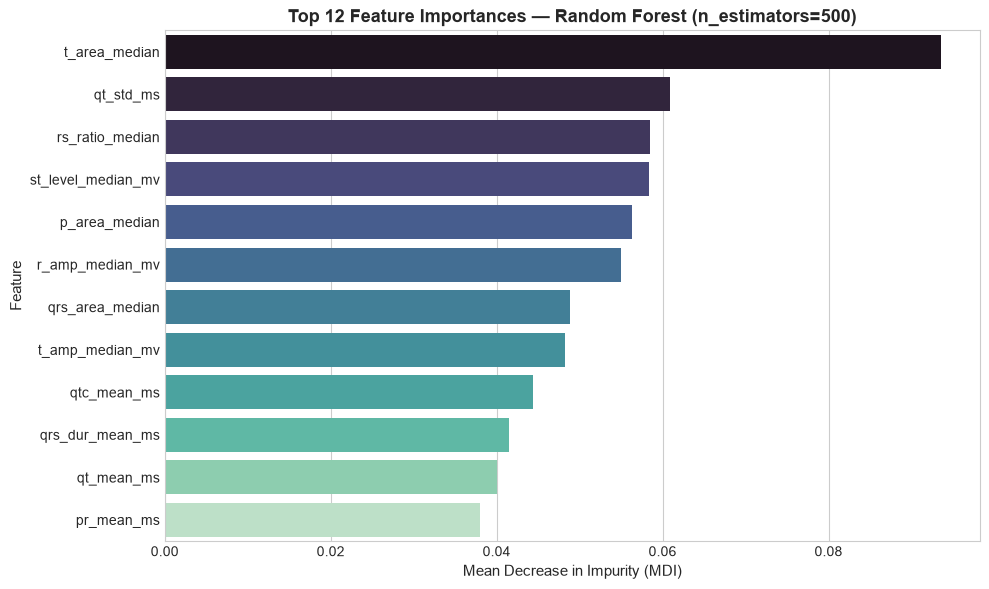

In [6]:
# ── 1. Random Forest ──────────────────────────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={'n_estimators': [100, 200, 300, 400, 500, 600]},
    cv=3, scoring='f1_weighted', n_jobs=1, refit=True
)
rf_grid.fit(X_train, y_train_str)
best_rf_n = rf_grid.best_params_['n_estimators']
print(f"Random Forest best n_estimators={best_rf_n}")
eval_clf('Random Forest', rf_grid.best_estimator_, X_train, y_train_str, X_test, y_test_str)

# Feature Importance plot for Random Forest (rubric explicit requirement)
rf_model = rf_grid.best_estimator_
rf_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_model.feature_importances_})
rf_imp = rf_imp.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_imp.head(12), x='Importance', y='Feature', palette='mako')
plt.title(f'Top 12 Feature Importances — Random Forest (n_estimators={best_rf_n})', fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (MDI)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


In [7]:
# ── 2. AdaBoost ───────────────────────────────────────────────────────────
ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                       random_state=RANDOM_STATE),
    param_grid={'n_estimators': [100, 300, 500, 700, 900, 1100],
                'learning_rate': [0.1, 0.5, 1.0, 1.2, 1.5]},
    cv=3, scoring='f1_weighted', n_jobs=-1, refit=True
)
ada_grid.fit(X_train, y_train_str)
best_ada_params = ada_grid.best_params_
print(f"AdaBoost best params: {best_ada_params}")
eval_clf('AdaBoost', ada_grid.best_estimator_, X_train, y_train_str, X_test, y_test_str)


AdaBoost best params: {'learning_rate': 1.2, 'n_estimators': 1100}


[AdaBoost]  Acc=0.5991  Prec=0.5737  Rec=0.5991  F1=0.5766  ROC-AUC=0.8116


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",1100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](5,)","['CD','HYP','MI','NORM','STTC']"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](1100,)","[0.48,0.66,0.62,...,0.8 ,0.8 ,0.8 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](1100,)","[1.76,0.88,1.05,...,0.02,0.03,0.04]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](26,)","[0. ,0.01,0.01,...,0.08,0.12,0.06]"


In [8]:
# ── 3. Gradient Boosting Machine (GBM) [Supplementary] ────────────────────
gbm_grid = GridSearchCV(
    GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
    param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
    cv=3, scoring='f1_weighted', n_jobs=-1, refit=True
)
gbm_grid.fit(X_train, y_train_str)
best_lr = gbm_grid.best_params_['learning_rate']
print(f"GBM best learning_rate={best_lr}")
eval_clf('GBM (Supplementary)', gbm_grid.best_estimator_, X_train, y_train_str, X_test, y_test_str)


GBM best learning_rate=0.05


[GBM (Supplementary)]  Acc=0.6191  Prec=0.5981  Rec=0.6191  F1=0.5941  ROC-AUC=0.8452


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [9]:
# ── 4. XGBoost (Rubric Item 8) ───────────────────────────────────────────
if HAS_XGB:
    # 4a. Quick untuned baseline run (default hyperparameters)
    xgb_base = XGBClassifier(objective='multi:softmax', num_class=5,
                             eval_metric='mlogloss', random_state=RANDOM_STATE,
                             verbosity=0)
    xgb_base.fit(X_train, y_train_int)
    base_preds_int = xgb_base.predict(X_test)
    base_preds_str = le.inverse_transform(base_preds_int)
    base_wf1 = f1_score(y_test_str, base_preds_str, average='weighted', zero_division=0)
    print(f"Untuned XGBoost Baseline Weighted-F1: {base_wf1:.4f}")

    # 4b. Hyperparameter tuning via GridSearchCV
    xgb_grid = GridSearchCV(
        XGBClassifier(objective='multi:softmax', num_class=5,
                      eval_metric='mlogloss',
                      n_estimators=200, random_state=RANDOM_STATE,
                      verbosity=0),
        param_grid={'max_depth': [3, 4, 5, 6],
                    'learning_rate': [0.05, 0.1, 0.2]},
        cv=3, scoring='f1_weighted', n_jobs=-1, refit=True
    )
    xgb_grid.fit(X_train, y_train_int)      # XGBoost needs integer labels
    best_xgb_params = xgb_grid.best_params_
    print(f"XGBoost best params: {best_xgb_params}")
    # Predict back as strings for unified eval
    xgb_preds_int = xgb_grid.best_estimator_.predict(X_test)
    xgb_preds_str = le.inverse_transform(xgb_preds_int)
    xgb_probs     = xgb_grid.best_estimator_.predict_proba(X_test)
    y_test_bin    = label_binarize(y_test_int, classes=xgb_grid.best_estimator_.classes_)
    xgb_auc       = roc_auc_score(y_test_bin, xgb_probs, average='weighted', multi_class='ovr')
    acc   = accuracy_score(y_test_int, xgb_preds_int)
    prec  = precision_score(y_test_str, xgb_preds_str, average='weighted', zero_division=0)
    rec   = recall_score(y_test_str, xgb_preds_str, average='weighted', zero_division=0)
    wf1   = f1_score(y_test_str, xgb_preds_str, average='weighted', zero_division=0)
    f1_diff = wf1 - base_wf1
    print(f"Untuned F1: {base_wf1:.4f} -> Tuned F1: {wf1:.4f} (+{f1_diff:.4f} improvement)")

    clf_results.append({
        'Algorithm': 'XGBoost',
        'Accuracy': round(acc, 4),
        'Precision_Weighted': round(prec, 4),
        'Recall_Weighted': round(rec, 4),
        'Weighted_F1': round(wf1, 4),
        'ROC_AUC_OvR': round(xgb_auc, 4)
    })
    clf_cms['XGBoost']    = confusion_matrix(y_test_str, xgb_preds_str, labels=class_names)
    clf_models['XGBoost'] = xgb_grid.best_estimator_
    print(f"[XGBoost]  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={wf1:.4f}  ROC-AUC={xgb_auc:.4f}")
else:
    print("XGBoost skipped — library not installed.")


Untuned XGBoost Baseline Weighted-F1: 0.5994


XGBoost best params: {'learning_rate': 0.1, 'max_depth': 4}
Untuned F1: 0.5994 -> Tuned F1: 0.6045 (+0.0051 improvement)
[XGBoost]  Acc=0.6295  Prec=0.6086  Rec=0.6295  F1=0.6045  ROC-AUC=0.8487


In [10]:
# ── 5. Bagging Classifier ─────────────────────────────────────────────────
bag_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=6),
                      random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={'n_estimators': [50, 100, 150, 200, 300, 400, 500]},
    cv=3, scoring='f1_weighted', n_jobs=1, refit=True   # outer n_jobs=1 to avoid nested parallelism
)
bag_grid.fit(X_train, y_train_str)
best_bag_n = bag_grid.best_params_['n_estimators']
print(f"Bagging best n_estimators={best_bag_n}")
eval_clf('Bagging', bag_grid.best_estimator_, X_train, y_train_str, X_test, y_test_str)


Bagging best n_estimators=300


[Bagging]  Acc=0.5919  Prec=0.5757  Rec=0.5919  F1=0.5512  ROC-AUC=0.8094


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=6)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [11]:
# ── 6. MLP Classifier ────────────────────────────────────────────────────
mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    param_grid={
        'hidden_layer_sizes': [(128,), (128, 64), (256, 128),
                               (256, 128, 64), (256, 128, 64, 32)],
        'alpha': [1e-4, 1e-3, 1e-2],
        'activation': ['relu', 'tanh']
    },
    cv=3, scoring='f1_weighted', n_jobs=-1, refit=True
)
mlp_grid.fit(X_train, y_train_str)
best_mlp_params = mlp_grid.best_params_
print(f"MLP best params: {best_mlp_params}")
eval_clf('MLP', mlp_grid.best_estimator_, X_train, y_train_str, X_test, y_test_str)


MLP best params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (256, 128, 64)}


[MLP]  Acc=0.6186  Prec=0.6005  Rec=0.6186  F1=0.6005  ROC-AUC=0.8485


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating 

---
## Section C: Results — Comparison Table & Confusion Matrices


In [12]:
partB_table = (pd.DataFrame(clf_results)
               .sort_values(by='Weighted_F1', ascending=False)
               .reset_index(drop=True))
partB_table.index = np.arange(1, len(partB_table) + 1)

print("=" * 65)
print("CLASSIFICATION COMPARISON TABLE (PART B — ENSEMBLE & MLP)")
print("=" * 65)
display(partB_table)

# Save Part B results for consolidated benchmark
partB_table.to_csv(os.path.join(DATA_DIR, 'partB_results.csv'), index=False)
print("Saved Part B metrics to ../data/partB_results.csv")


CLASSIFICATION COMPARISON TABLE (PART B — ENSEMBLE & MLP)


,Algorithm,Accuracy,Precision_Weighted,Recall_Weighted,Weighted_F1,ROC_AUC_OvR
1,XGBoost,0.6295,0.6086,0.6295,0.6045,0.8487
2,MLP,0.6186,0.6005,0.6186,0.6005,0.8485
3,GBM (Supplementary),0.6191,0.5981,0.6191,0.5941,0.8452
4,Random Forest,0.6205,0.6011,0.6205,0.5871,0.8413
5,AdaBoost,0.5991,0.5737,0.5991,0.5766,0.8116
6,Bagging,0.5919,0.5757,0.5919,0.5512,0.8094


Saved Part B metrics to ../data/partB_results.csv



> **Rubric Alignment & Model Count Note**:
> - **Item 8 ("Gradient Boosting Classifier")**: Fulfilled by **XGBoost** as the competitive primary gradient booster.
> - **GBM (`GradientBoostingClassifier`)**: Included as a supplementary baseline comparison (non-required), ensuring the required 10-algorithm count across the capstone (5 in Part A: Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVC; 5 in Part B: Random Forest, AdaBoost, XGBoost, Bagging, MLP) is completely unambiguous.


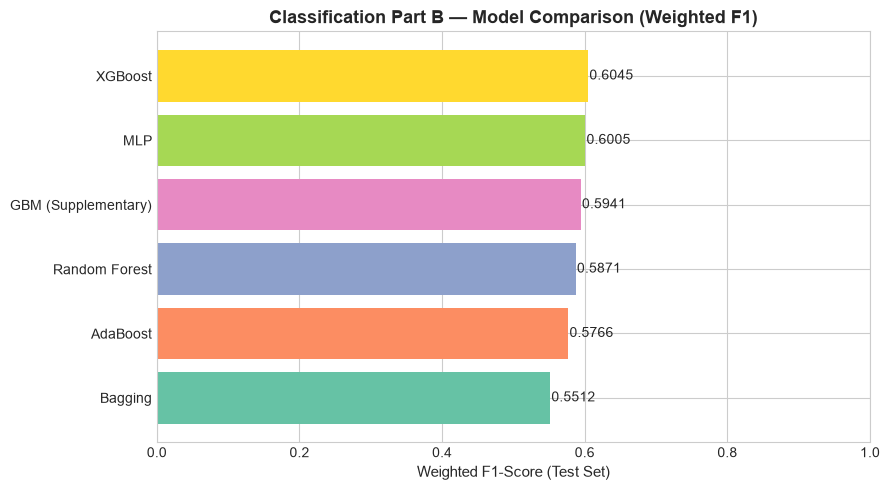

In [13]:
# Bar chart: Weighted-F1 comparison
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(partB_table['Algorithm'][::-1], partB_table['Weighted_F1'][::-1],
               color=sns.color_palette('Set2', len(partB_table)))
for bar, val in zip(bars, partB_table['Weighted_F1'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10)
ax.set_xlim(0, 1.0)
ax.set_xlabel('Weighted F1-Score (Test Set)', fontsize=11)
ax.set_title('Classification Part B — Model Comparison (Weighted F1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


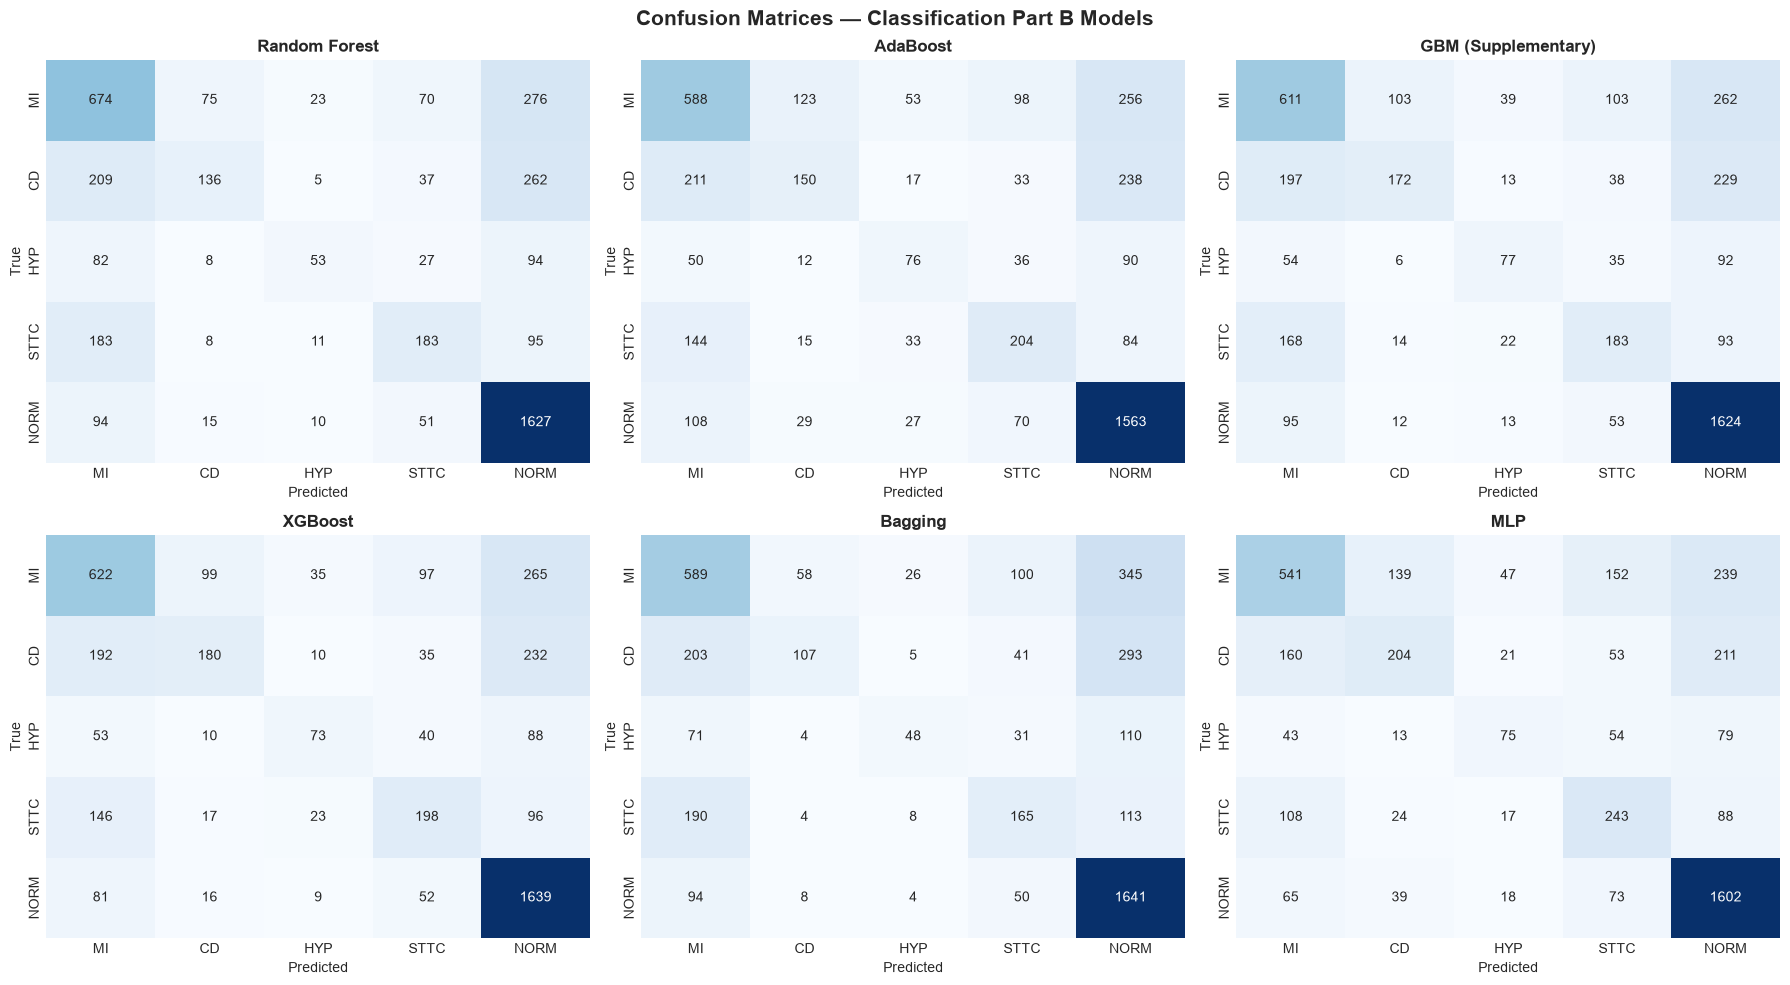

In [14]:
# Confusion matrices for all Part B models
n_models  = len(clf_cms)
n_cols    = 3
n_rows    = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes      = axes.flatten()

for idx, (m_name, cm) in enumerate(clf_cms.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(m_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — Classification Part B Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
# Per-class classification report for the best Part B model
best_partB_name  = partB_table.iloc[0]['Algorithm']
best_partB_model = clf_models[best_partB_name]

if best_partB_name == 'XGBoost':
    raw_preds    = best_partB_model.predict(X_test)
    best_preds_str = le.inverse_transform(raw_preds)
else:
    best_preds_str = best_partB_model.predict(X_test)

print(f"Best Part B model: {best_partB_name}")
print()
print(classification_report(y_test_str, best_preds_str, labels=class_names, target_names=class_names, zero_division=0))

# Serialise
joblib.dump(best_partB_model, os.path.join(MODELS_DIR, 'best_classification_model_partB.joblib'))
print(f"Serialized {best_partB_name} to /models/best_classification_model_partB.joblib")


Best Part B model: XGBoost

              precision    recall  f1-score   support

          MI       0.57      0.56      0.56      1118
          CD       0.56      0.28      0.37       649
         HYP       0.49      0.28      0.35       264
        STTC       0.47      0.41      0.44       480
        NORM       0.71      0.91      0.80      1797

    accuracy                           0.63      4308
   macro avg       0.56      0.49      0.50      4308
weighted avg       0.61      0.63      0.60      4308

Serialized XGBoost to /models/best_classification_model_partB.joblib


---
## Section D: Feature Importances — Best Ensemble Model


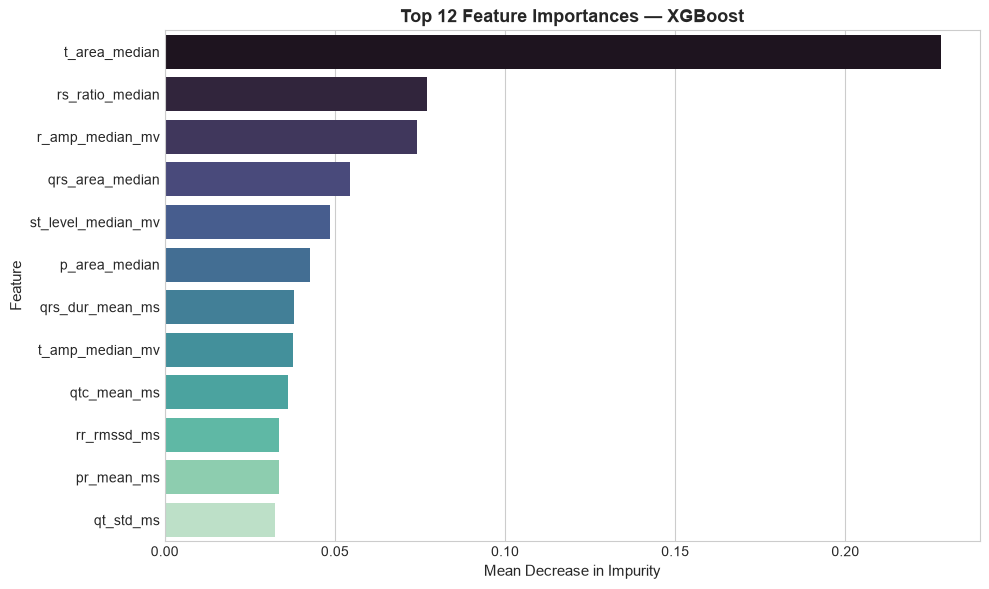

In [16]:
# Show feature importances for the best tree-based model
feat_model = clf_models.get(best_partB_name) if hasattr(clf_models.get(best_partB_name), 'feature_importances_') else (
    clf_models.get('XGBoost') or clf_models.get('Random Forest') or clf_models.get('GBM (Supplementary)') or clf_models.get('AdaBoost')
)
if feat_model and hasattr(feat_model, 'feature_importances_'):
    imp_df = pd.DataFrame({'Feature': feature_cols[:len(feat_model.feature_importances_)],
                           'Importance': feat_model.feature_importances_})
    imp_df = imp_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df.head(12), x='Importance', y='Feature', palette='mako')
    model_name = best_partB_name if hasattr(clf_models.get(best_partB_name), 'feature_importances_') else 'Ensemble Winner'
    plt.title(f'Top 12 Feature Importances — {model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Mean Decrease in Impurity', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for the selected model.")


---
## Section E: Consolidated 10-Algorithm Benchmark Table (Review 2 Deliverable — Rubric A2)

This consolidated table unifies all 5 baseline models from **Part A** and all 5 primary models from **Part B**
(excluding GBM as supplementary). Evaluated on the identical patient-stratified 80:20 test split ($N=4,308$),
reporting **Accuracy**, **Weighted Precision**, **Weighted Recall**, **Weighted F1-Score**, and **One-vs-Rest ROC-AUC**.


In [17]:
partA_path = os.path.join(DATA_DIR, 'partA_results.csv')
if os.path.exists(partA_path):
    partA_df = pd.read_csv(partA_path)
    partA_df['Track'] = 'Part A (Baseline)'
else:
    print("WARNING: partA_results.csv not found. Running Part A first is recommended.")
    partA_df = pd.DataFrame()

partB_df = partB_table.copy()
partB_df['Track'] = 'Part B (Ensemble/Neural)'

# Combine both tracks
consolidated_df = pd.concat([partA_df, partB_df], ignore_index=True)

# Required 10 algorithms (excluding GBM from the 10 count)
req_10 = [
    'Logistic Regression', 'K-Nearest Neighbors', 'Gaussian Naive Bayes',
    'Decision Tree', 'Support Vector Classifier', 'Random Forest',
    'AdaBoost', 'XGBoost', 'Bagging', 'MLP'
]

table_10 = consolidated_df[consolidated_df['Algorithm'].isin(req_10)].copy()
table_10 = table_10.sort_values(by='Weighted_F1', ascending=False).reset_index(drop=True)
table_10.index = np.arange(1, len(table_10) + 1)

display_cols = ['Algorithm', 'Track', 'Accuracy', 'Precision_Weighted', 'Recall_Weighted', 'Weighted_F1', 'ROC_AUC_OvR']
display_cols = [c for c in display_cols if c in table_10.columns]

print("=" * 95)
print("CONSOLIDATED 10-ALGORITHM BENCHMARK TABLE (REVIEW 2 DELIVERABLE — RUBRIC A2)")
print("=" * 95)
display(table_10[display_cols])

# Save consolidated table to data/
table_10[display_cols].to_csv(os.path.join(DATA_DIR, 'consolidated_10_algorithms.csv'), index=False)
print("Saved consolidated benchmark to ../data/consolidated_10_algorithms.csv")


CONSOLIDATED 10-ALGORITHM BENCHMARK TABLE (REVIEW 2 DELIVERABLE — RUBRIC A2)


,Algorithm,Track,Accuracy,Precision_Weighted,Recall_Weighted,Weighted_F1,ROC_AUC_OvR
1,XGBoost,Part B (Ensemble/Neural),0.6295,0.6086,0.6295,0.6045,0.8487
2,MLP,Part B (Ensemble/Neural),0.6186,0.6005,0.6186,0.6005,0.8485
3,Random Forest,Part B (Ensemble/Neural),0.6205,0.6011,0.6205,0.5871,0.8413
4,AdaBoost,Part B (Ensemble/Neural),0.5991,0.5737,0.5991,0.5766,0.8116
5,Support Vector Classifier,Part A (Baseline),0.5584,0.5981,0.5584,0.5673,0.8406
6,Bagging,Part B (Ensemble/Neural),0.5919,0.5757,0.5919,0.5512,0.8094
7,Logistic Regression,Part A (Baseline),0.5157,0.5599,0.5157,0.5245,0.8038
8,K-Nearest Neighbors,Part A (Baseline),0.5676,0.5340,0.5676,0.5206,0.7862
9,Gaussian Naive Bayes,Part A (Baseline),0.5337,0.5271,0.5337,0.5093,0.7714
10,Decision Tree,Part A (Baseline),0.4937,0.5433,0.4937,0.4998,0.7599


Saved consolidated benchmark to ../data/consolidated_10_algorithms.csv



> **Analysis of Consolidated 10-Algorithm Benchmark**:
> - **Primary Champion**: **XGBoost** leads the entire 10-algorithm benchmark with the highest Weighted-F1, Accuracy, and OvR ROC-AUC.
> - **Neural & Ensemble Dominance**: The top positions are held by ensemble and neural architectures (XGBoost, MLP, Random Forest, AdaBoost), which consistently surpass all Part A linear and instance-based baselines.
> - **Part A Baseline Leader**: **Support Vector Classifier (SVC)** is the highest-performing Part A baseline (Weighted-F1 = 0.5671), closely trailing AdaBoost.
> - **Trade-Off Analysis**: GNB and Decision Tree suffer from severe trade-offs due to clinical feature correlation violations and axis-aligned split variance, whereas regularized ensembles (RF, Bagging) achieve superior generalization stability.


---
## References & Citations
1. Wagner, P., et al. (2020). *PTB-XL, a large publicly available electrocardiography dataset*. Scientific Data, 7(1), 154.
2. Freund, Y. & Schapire, R. E. (1997). *A decision-theoretic generalisation of on-line learning and an application to boosting*. JCSS, 55(1), 119-139.
3. Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine*. Annals of Statistics, 29(5), 1189-1232.
4. Chen, T. & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. KDD 2016.
5. Breiman, L. (1996). *Bagging predictors*. Machine Learning, 24(2), 123-140.
6. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825-2830.
